# The Kalman Filter

This notebook covers the **Kalman Filter** (KF), the optimal recursive estimator for linear dynamical systems with Gaussian noise.

### What we cover
1. **Mathematical derivation** — the predict-update cycle
2. **1D scalar tracking** — intuition for Kalman gain and error covariance
3. **Multivariate tracking** — 2D position estimation with covariance ellipses
4. **Sensitivity analysis** — how mismatched Q and R affect performance

The KF is the backbone of modern navigation, tracking, sensor fusion, and econometrics.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## 1. Mathematical Foundation

Consider the discrete-time state-space model:

**State equation:**
$$x_k = F x_{k-1} + B u_{k-1} + w_{k-1}, \quad w_{k-1} \sim \mathcal{N}(0, Q)$$

**Observation equation:**
$$z_k = H x_k + v_k, \quad v_k \sim \mathcal{N}(0, R)$$

The Kalman filter operates in two phases:

### Predict (Time Update)
$$\hat{x}_{k|k-1} = F \hat{x}_{k-1|k-1} + B u_{k-1}$$
$$P_{k|k-1} = F P_{k-1|k-1} F^{\top} + Q$$

### Update (Measurement Update)
$$y_k = z_k - H \hat{x}_{k|k-1} \quad \text{(innovation)}$$
$$S_k = H P_{k|k-1} H^{\top} + R \quad \text{(innovation covariance)}$$
$$K_k = P_{k|k-1} H^{\top} S_k^{-1} \quad \text{(Kalman gain)}$$
$$\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k y_k$$
$$P_{k|k} = (I - K_k H) P_{k|k-1}$$

**Optimality:** For linear-Gaussian systems, the KF minimizes the mean-squared error. It is the Bayesian posterior mean.


In [8]:
class KalmanFilter1D:
    """
    Scalar Kalman filter for state-space model:
    x_k = F*x_{k-1} + w,  w ~ N(0,Q)
    z_k = H*x_k + v,      v ~ N(0,R)
    """
    def __init__(self, x0, P0, F=1.0, H=1.0, Q=0.01, R=1.0):
        self.x = float(x0)
        self.P = float(P0)
        self.F = float(F)
        self.H = float(H)
        self.Q = float(Q)
        self.R = float(R)
        self.x_est = []
        self.P_est = []
        self.K_hist = []
    
    def predict(self, u=0.0, B=0.0):
        self.x = self.F * self.x + B * u
        self.P = self.F * self.P * self.F + self.Q
    
    def update(self, z):
        y = z - self.H * self.x
        S = self.H * self.P * self.H + self.R
        K = self.P * self.H / S
        self.x = self.x + K * y
        self.P = (1.0 - K * self.H) * self.P
        self.x_est.append(self.x)
        self.P_est.append(self.P)
        self.K_hist.append(K)


## 2. One-Dimensional Tracking Example

We track a slowly varying true state (random walk) observed with additive Gaussian noise. The Kalman filter smooths the measurements and provides uncertainty bounds that should contain the true state approximately 95% of the time (2-sigma).


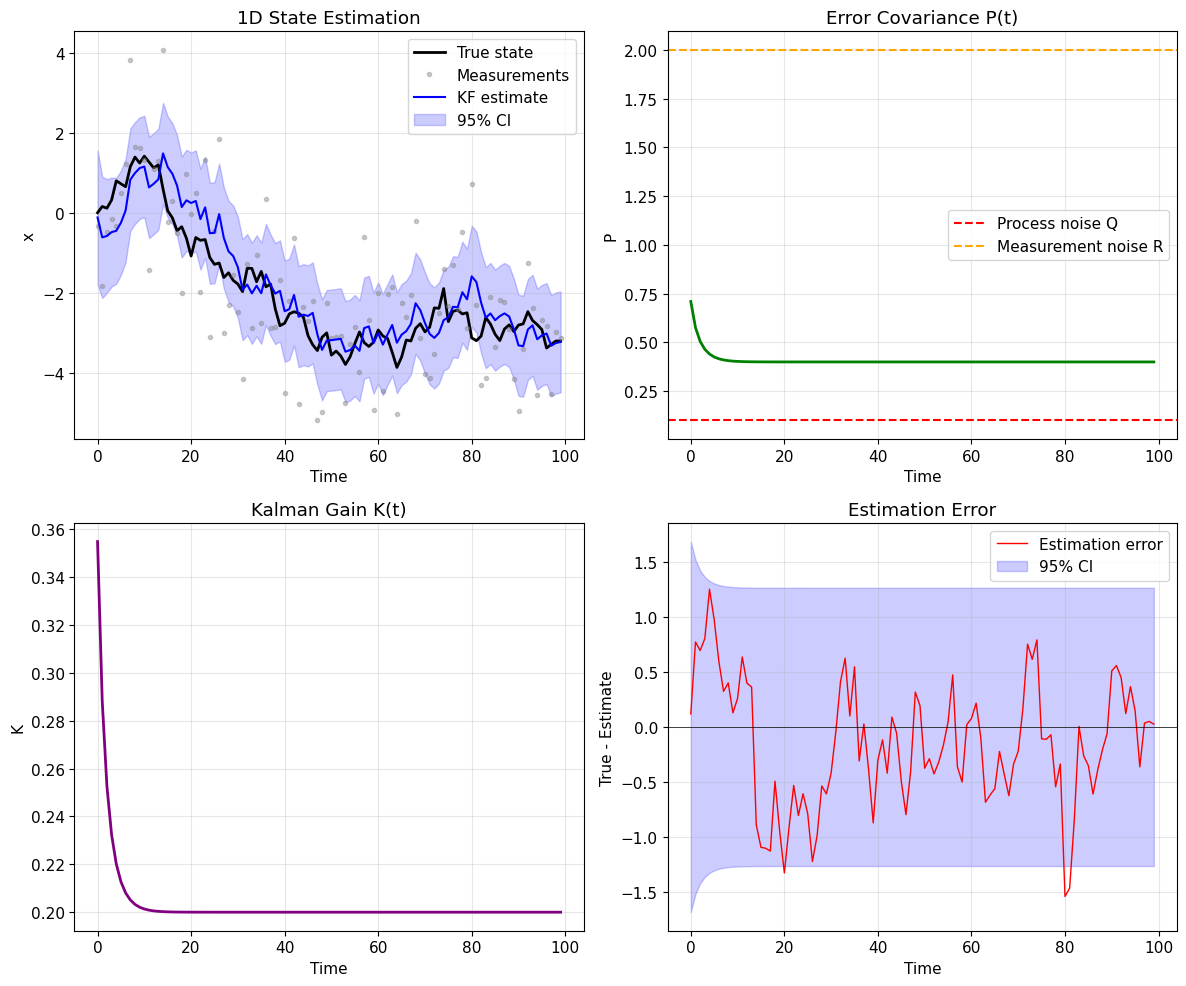

RMSE of KF estimate:      0.5895
RMSE of raw measurements: 1.3329


In [9]:
T = 100
Q_true = 0.1
R_true = 2.0

# Generate true state (random walk)
x_true = np.zeros(T)
x_true[0] = 0.0
for t in range(1, T):
    x_true[t] = x_true[t-1] + np.sqrt(Q_true) * np.random.randn()

# Noisy measurements
z_meas = x_true + np.sqrt(R_true) * np.random.randn(T)

# Run Kalman filter
kf = KalmanFilter1D(x0=0.0, P0=1.0, F=1.0, H=1.0, Q=Q_true, R=R_true)
for t in range(T):
    kf.predict()
    kf.update(z_meas[t])

x_est = np.array(kf.x_est)
P_est = np.array(kf.P_est)
K_est = np.array(kf.K_hist)
std_est = np.sqrt(P_est)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].plot(range(T), x_true, 'k-', lw=2, label='True state')
axes[0, 0].plot(range(T), z_meas, 'o', alpha=0.4, markersize=3, color='gray', label='Measurements')
axes[0, 0].plot(range(T), x_est, 'b-', lw=1.5, label='KF estimate')
axes[0, 0].fill_between(range(T), x_est - 2*std_est, x_est + 2*std_est,
                        alpha=0.2, color='blue', label='95% CI')
axes[0, 0].set_title('1D State Estimation')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('x')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(range(T), P_est, 'g-', lw=2)
axes[0, 1].axhline(Q_true, color='red', linestyle='--', label='Process noise Q')
axes[0, 1].axhline(R_true, color='orange', linestyle='--', label='Measurement noise R')
axes[0, 1].set_title('Error Covariance P(t)')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('P')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(range(T), K_est, 'purple', lw=2)
axes[1, 0].set_title('Kalman Gain K(t)')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('K')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(range(T), x_true - x_est, 'r-', lw=1, label='Estimation error')
axes[1, 1].fill_between(range(T), -2*std_est, 2*std_est,
                        alpha=0.2, color='blue', label='95% CI')
axes[1, 1].axhline(0, color='black', lw=0.5)
axes[1, 1].set_title('Estimation Error')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('True - Estimate')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

rmse_kf = np.sqrt(np.mean((x_true - x_est)**2))
rmse_raw = np.sqrt(np.mean((x_true - z_meas)**2))
print("RMSE of KF estimate:      {:.4f}".format(rmse_kf))
print("RMSE of raw measurements: {:.4f}".format(rmse_raw))


## 3. Multivariate Kalman Filter: 2D Tracking

State vector: $s_k = [x, y, v_x, v_y]^{\top}$

**Constant velocity model:**
$$s_k = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} s_{k-1} + w_{k-1}$$

We observe only position:
$$z_k = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix} s_k + v_k$$

We visualize the position covariance as error ellipses at selected time steps.


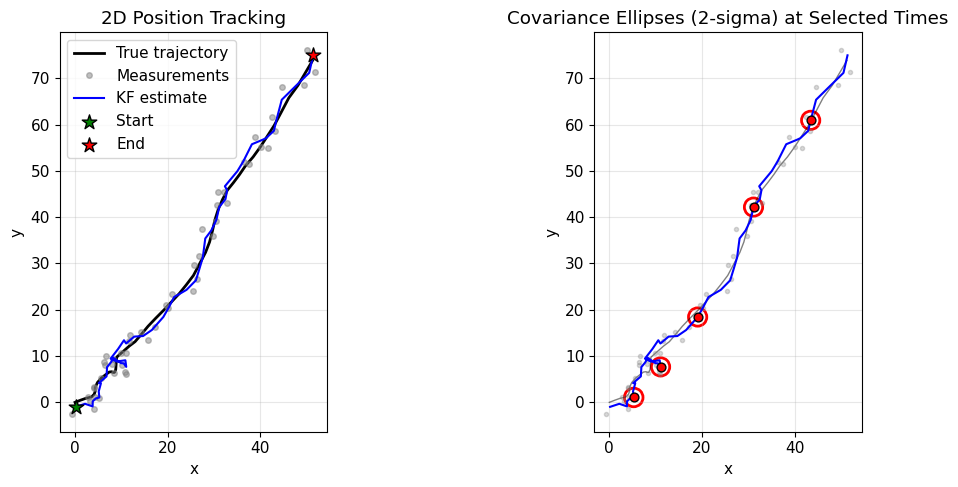

Position RMSE (KF):  1.0923
Position RMSE (raw): 1.5152


In [10]:
class KalmanFilter:
    """Multivariate Kalman filter."""
    def __init__(self, x, P, F, H, Q, R):
        self.x = x.copy()
        self.P = P.copy()
        self.F = F.copy()
        self.H = H.copy()
        self.Q = Q.copy()
        self.R = R.copy()
        self.x_hist = []
        self.P_hist = []
    
    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
    
    def update(self, z):
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        I = np.eye(len(self.x))
        self.P = (I - K @ self.H) @ self.P
        self.x_hist.append(self.x.copy())
        self.P_hist.append(self.P.copy())

dt = 1.0
F = np.array([[1.0, 0.0, dt, 0.0],
              [0.0, 1.0, 0.0, dt],
              [0.0, 0.0, 1.0, 0.0],
              [0.0, 0.0, 0.0, 1.0]])
H = np.array([[1.0, 0.0, 0.0, 0.0],
              [0.0, 1.0, 0.0, 0.0]])
Q = 0.1 * np.array([[dt**3/3, 0.0, dt**2/2, 0.0],
                    [0.0, dt**3/3, 0.0, dt**2/2],
                    [dt**2/2, 0.0, dt, 0.0],
                    [0.0, dt**2/2, 0.0, dt]])
R = np.array([[2.0, 0.0], [0.0, 2.0]])
x0 = np.array([0.0, 0.0, 1.0, 0.5])
P0 = np.eye(4)

# Generate true trajectory
T2 = 50
x_true_mv = np.zeros((T2, 4))
x_true_mv[0] = x0
for t in range(1, T2):
    x_true_mv[t] = F @ x_true_mv[t-1] + np.random.multivariate_normal(np.zeros(4), Q)

z_meas_mv = np.zeros((T2, 2))
for t in range(T2):
    z_meas_mv[t] = H @ x_true_mv[t] + np.random.multivariate_normal(np.zeros(2), R)

kf_mv = KalmanFilter(x0, P0, F, H, Q, R)
for t in range(T2):
    kf_mv.predict()
    kf_mv.update(z_meas_mv[t])

x_est_mv = np.array(kf_mv.x_hist)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Trajectory plot
axes[0].plot(x_true_mv[:, 0], x_true_mv[:, 1], 'k-', lw=2, label='True trajectory')
axes[0].plot(z_meas_mv[:, 0], z_meas_mv[:, 1], 'o', alpha=0.5, markersize=4,
             color='gray', label='Measurements')
axes[0].plot(x_est_mv[:, 0], x_est_mv[:, 1], 'b-', lw=1.5, label='KF estimate')
axes[0].scatter(x_est_mv[0, 0], x_est_mv[0, 1], c='green', s=120, marker='*',
                zorder=5, edgecolors='black', label='Start')
axes[0].scatter(x_est_mv[-1, 0], x_est_mv[-1, 1], c='red', s=120, marker='*',
                zorder=5, edgecolors='black', label='End')
axes[0].set_title('2D Position Tracking')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Covariance ellipses at selected times
ax2 = axes[1]
ax2.plot(x_true_mv[:, 0], x_true_mv[:, 1], 'k-', lw=1, alpha=0.5)
ax2.plot(z_meas_mv[:, 0], z_meas_mv[:, 1], 'o', alpha=0.3, markersize=3, color='gray')
ax2.plot(x_est_mv[:, 0], x_est_mv[:, 1], 'b-', lw=1.5)

for t in [5, 15, 25, 35, 45]:
    cov_xy = kf_mv.P_hist[t][:2, :2]
    mean_xy = x_est_mv[t, :2]
    eigvals, eigvecs = np.linalg.eigh(cov_xy)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    width, height = 2 * 2.0 * np.sqrt(eigvals)
    ellipse = Ellipse(xy=mean_xy, width=width, height=height, angle=angle,
                      edgecolor='red', facecolor='none', lw=2)
    ax2.add_patch(ellipse)
    ax2.scatter(mean_xy[0], mean_xy[1], c='red', s=40, zorder=5, edgecolors='black')

ax2.set_title('Covariance Ellipses (2-sigma) at Selected Times')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

rmse_pos_kf = np.sqrt(np.mean((x_true_mv[:, :2] - x_est_mv[:, :2])**2))
rmse_pos_raw = np.sqrt(np.mean((x_true_mv[:, :2] - z_meas_mv)**2))
print("Position RMSE (KF):  {:.4f}".format(rmse_pos_kf))
print("Position RMSE (raw): {:.4f}".format(rmse_pos_raw))


## 4. Sensitivity to Process and Measurement Noise

The Kalman filter requires specifying $Q$ and $R$. In practice these are often unknown or only approximately known.

- **Q too small:** The filter trusts the model too much. It becomes sluggish and lags behind true state changes.
- **Q too large:** The filter trusts measurements too much. The estimate becomes noisy.
- **R too small:** The filter overfits to measurements, tracking noise rather than signal.
- **R too large:** The filter ignores measurements, relying almost entirely on the model prediction.

We demonstrate this by running the 1D filter with deliberately mismatched parameters.


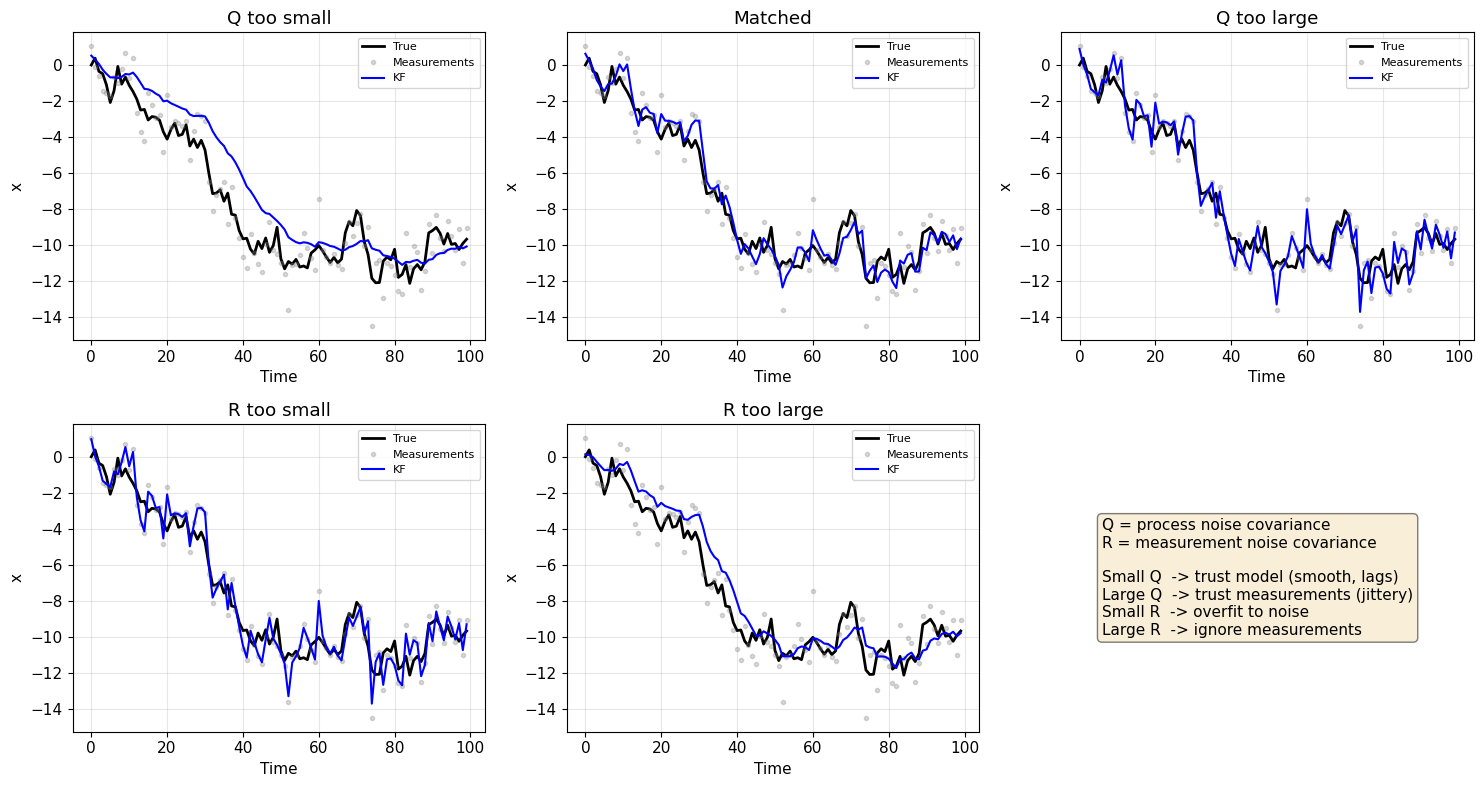

In [11]:
T_sens = 100
Q_true_s = 0.5
R_true_s = 1.0

x_true_s = np.zeros(T_sens)
x_true_s[0] = 0.0
for t in range(1, T_sens):
    x_true_s[t] = x_true_s[t-1] + np.sqrt(Q_true_s) * np.random.randn()
z_s = x_true_s + np.sqrt(R_true_s) * np.random.randn(T_sens)

configs = [
    (0.01, 1.0, 'Q too small'),
    (0.5, 1.0, 'Matched'),
    (5.0, 1.0, 'Q too large'),
    (0.5, 0.1, 'R too small'),
    (0.5, 10.0, 'R too large')
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (Q_test, R_test, label) in enumerate(configs):
    kf_s = KalmanFilter1D(x0=0.0, P0=1.0, F=1.0, H=1.0, Q=Q_test, R=R_test)
    for t in range(T_sens):
        kf_s.predict()
        kf_s.update(z_s[t])
    x_e = np.array(kf_s.x_est)
    
    axes[idx].plot(range(T_sens), x_true_s, 'k-', lw=2, label='True')
    axes[idx].plot(range(T_sens), z_s, 'o', alpha=0.3, markersize=3,
                   color='gray', label='Measurements')
    axes[idx].plot(range(T_sens), x_e, 'b-', lw=1.5, label='KF')
    axes[idx].set_title('{}'.format(label))
    axes[idx].set_xlabel('Time')
    axes[idx].set_ylabel('x')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

# Summary text in last subplot
axes[-1].axis('off')
axes[-1].text(0.1, 0.5,
              'Q = process noise covariance\n'
              'R = measurement noise covariance\n\n'
              'Small Q  -> trust model (smooth, lags)\n'
              'Large Q  -> trust measurements (jittery)\n'
              'Small R  -> overfit to noise\n'
              'Large R  -> ignore measurements',
              transform=axes[-1].transAxes, fontsize=11, verticalalignment='center',
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


## 5. Summary

| Quantity | Role |
|----------|------|
| **Predict** | Propagate state and grow uncertainty via process noise $Q$ |
| **Update** | Fuse measurement, reduce uncertainty via Kalman gain $K$ |
| **$K$** | Optimal blending factor: large when measurements are reliable (small $R$) |
| **$P$** | Error covariance: converges to steady-state if the system is time-invariant |
| **Innovation** | $y_k = z_k - H \hat{x}_{k|k-1}$: should be white noise if the filter is optimal |

### Key Properties
- **Optimality:** Minimum mean-squared error (MMSE) estimator for linear-Gaussian systems.
- **Recursive:** Only the current estimate and covariance are needed; no storage of full history.
- **Computational cost:** $O(d^3)$ per step due to the matrix inversion in $S$ (can be reduced via square-root or sequential update formulations).
- **Extensions:** Extended Kalman Filter (EKF) for nonlinear dynamics, Unscented Kalman Filter (UKF) for better nonlinear handling, and Ensemble Kalman Filter (EnKF) for high-dimensional geophysical systems.

The Kalman filter remains the cornerstone of modern tracking, navigation (GPS/INS fusion), and real-time sensor processing.
